In [24]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import cmocean
import xarray as xr
import pylab as pl
from mpl_toolkits.axes_grid1 import make_axes_locatable
from scipy.io import loadmat
from scipy.stats import chi2
from matplotlib.colors import LogNorm

In [26]:

coasto='../datafiles/realistic'

pathVELo=str(coasto) + '/WVELAC.nc'
dsVELo= xr.open_dataset(pathVELo)
WVELo=dsVELo.Valorig.values
distVELo=dsVELo.dist.values

TIMEVELo=dsVELo.time.values

lat_acVELo=dsVELo.latAC.values
lon_acVELo=dsVELo.lonAC.values


coast='../datafiles/smooth'
pathVEL=str(coast) + '/WVELAC.nc'
dsVEL= xr.open_dataset(pathVEL)

WVEL=dsVEL.Valorig.values
distVEL=dsVEL.dist.values

TIMEVEL=dsVEL.time.values/60

lat_acVEL=dsVEL.latAC.values
lon_acVEL=dsVEL.lonAC.values


In [27]:
def welch_dof(nperseg=256, noverlap=128, nseg=None, window='hann'):
    """
    Compute effective degrees of freedom for Welch PSD using
    window autocorrelation (Percival & Walden style).

    Parameters
    ----------
    nperseg : int
        Segment length
    noverlap : int
        Overlap between segments
    nseg : int
        Number of segments used in averaging
    window : str
        Window type ('hann' supported)

    Returns
    -------
    nu : float
        Effective degrees of freedom
    Keff : float
        Effective number of independent averages
    rho : array
        Correlation coefficients between segments
    """

    if nseg is None:
        raise ValueError("You must provide nseg")

    step = nperseg - noverlap

    # window
    if window == 'hann':
        w = np.hanning(nperseg)
    else:
        raise ValueError("Only 'hann' implemented")

    # normalize window energy
    w = w / np.sqrt(np.sum(w**2))

    # number of overlapping neighbors to consider
    max_lag = (nperseg - 1) // step

    rho = []

    for m in range(1, max_lag + 1):
        shift = m * step

        if shift >= nperseg:
            break

        # overlap region
        overlap = np.dot(w[:nperseg-shift], w[shift:])
        rho.append(overlap)

    rho = np.array(rho)

    # effective number of independent averages
    Keff = nseg / (1 + 2 * np.sum(rho**2))

    # degrees of freedom
    nu = 2 * Keff

    return nu, Keff, rho

In [28]:
def psd_uncertainty_factors(nu, alpha=0.05):
    chi2_low = chi2.ppf(alpha / 2, nu)
    chi2_high = chi2.ppf(1 - alpha / 2, nu)

    lower_factor = nu / chi2_high
    upper_factor = nu / chi2_low

    return lower_factor, upper_factor

In [29]:
def FFRQ_overlap(Wfilt):
    dt=1200
    nperseg=256
    noverlap=128
    
    fs = 1 / dt
    N, nx = Wfilt.shape
    
    step = nperseg - noverlap
    nseg = (N - noverlap) // step
    
    nt = nperseg // 2 + 1
    psd = np.zeros((nx, nt))
    
    window = np.hanning(nperseg)
    U = (1 / nperseg) * np.sum(window**2)
    
    for ii in range(nx):
    
        x = Wfilt[:, ii]
        psd_accum = np.zeros(nt)
    
        for jj in range(nseg):
            start = jj * step
            end = start + nperseg
    
            if end > N:
                break
    
            segment = x[start:end]-np.mean(x[start:end])
            xw = segment * window
    
            xdft = np.fft.rfft(xw)
            psdx = (1 / (fs * nperseg * U)) * np.abs(xdft)**2
            psdx[1:-1] *= 2
    
            psd_accum += psdx
    
        psd[ii, :] = psd_accum / nseg  # average
    
    freq = np.fft.rfftfreq(nperseg, d=dt)
    
    return psd[:,1:], freq[1:]

In [30]:
nperseg = 256
noverlap = 128
step = nperseg - noverlap
nseg = (WVEL[72:].shape[0] - noverlap) // step

nu, Keff, rho = welch_dof(nperseg, noverlap, nseg)

print("DOF:", nu)

DOF: 5.69349304310526


In [31]:
lf,uf=psd_uncertainty_factors(nu)

In [32]:
psdfilt, freqfilt=FFRQ_overlap(WVEL[72:]) 
psdfilto, freqfilto=FFRQ_overlap(WVELo) 

In [33]:
def closest(lat,indlat,lon,indlon):
    loclat=[]
    loclon=[]
    for i in range(len(indlat)):
        loclat.append(np.where(lat>=indlat[i])[0][0])
        loclon.append(np.where(lon<=indlon[i])[0][0])
    return loclat,loclon

In [34]:
ind_lon_cities = [ -115.939167, -116.605833, -117.1625]
ind_lat_cities = [ 30.556389, 31.857778, 32.715]

ind_lat,ind_lon=closest(lat_acVEL,ind_lat_cities,lon_acVEL,ind_lon_cities)

In [35]:
matfile=loadmat( '../datafiles/PALL.mat')
dep=matfile['d'][0][:11]
latout=matfile['lat'][0][:11]
lonout=matfile['lon'][0][:11]

In [36]:
#Only for at depth smooth!! 

latloc=[]
lonloc=[]

for i in range(len(dep)):
    ind=np.where(dep[i][0]>=500)[0][0]
    latloc.append(latout[i][0][ind])
    lonloc.append(lonout[i][0][ind])
    
loclatIn,loclonIn=closest(lat_acVEL,latloc,lon_acVEL,lonloc)


#Only for at depth Org

latlocorg=[]
lonlocorg=[]

for i in range(len(dep)):
    ind=np.where(dep[i][0]>=500)[0][0]
    latlocorg.append(latout[i][0][ind])
    lonlocorg.append(lonout[i][0][ind])
    
loclatInorg,loclonInorg=closest(lat_acVELo,latlocorg,lon_acVELo,lonlocorg)


In [37]:
end=np.where(lat_acVEL>33.5)[0][0]
endOrg=np.where(lat_acVELo>33.5)[0][0]

In [40]:
params = {'font.size': 10,
          'figure.figsize': (7.48, 6.732),
         'font.family':'sans'}
pl.rcParams.update(params)
plt.rcParams['figure.dpi'] = 300
plt.rcParams['savefig.dpi'] = 300

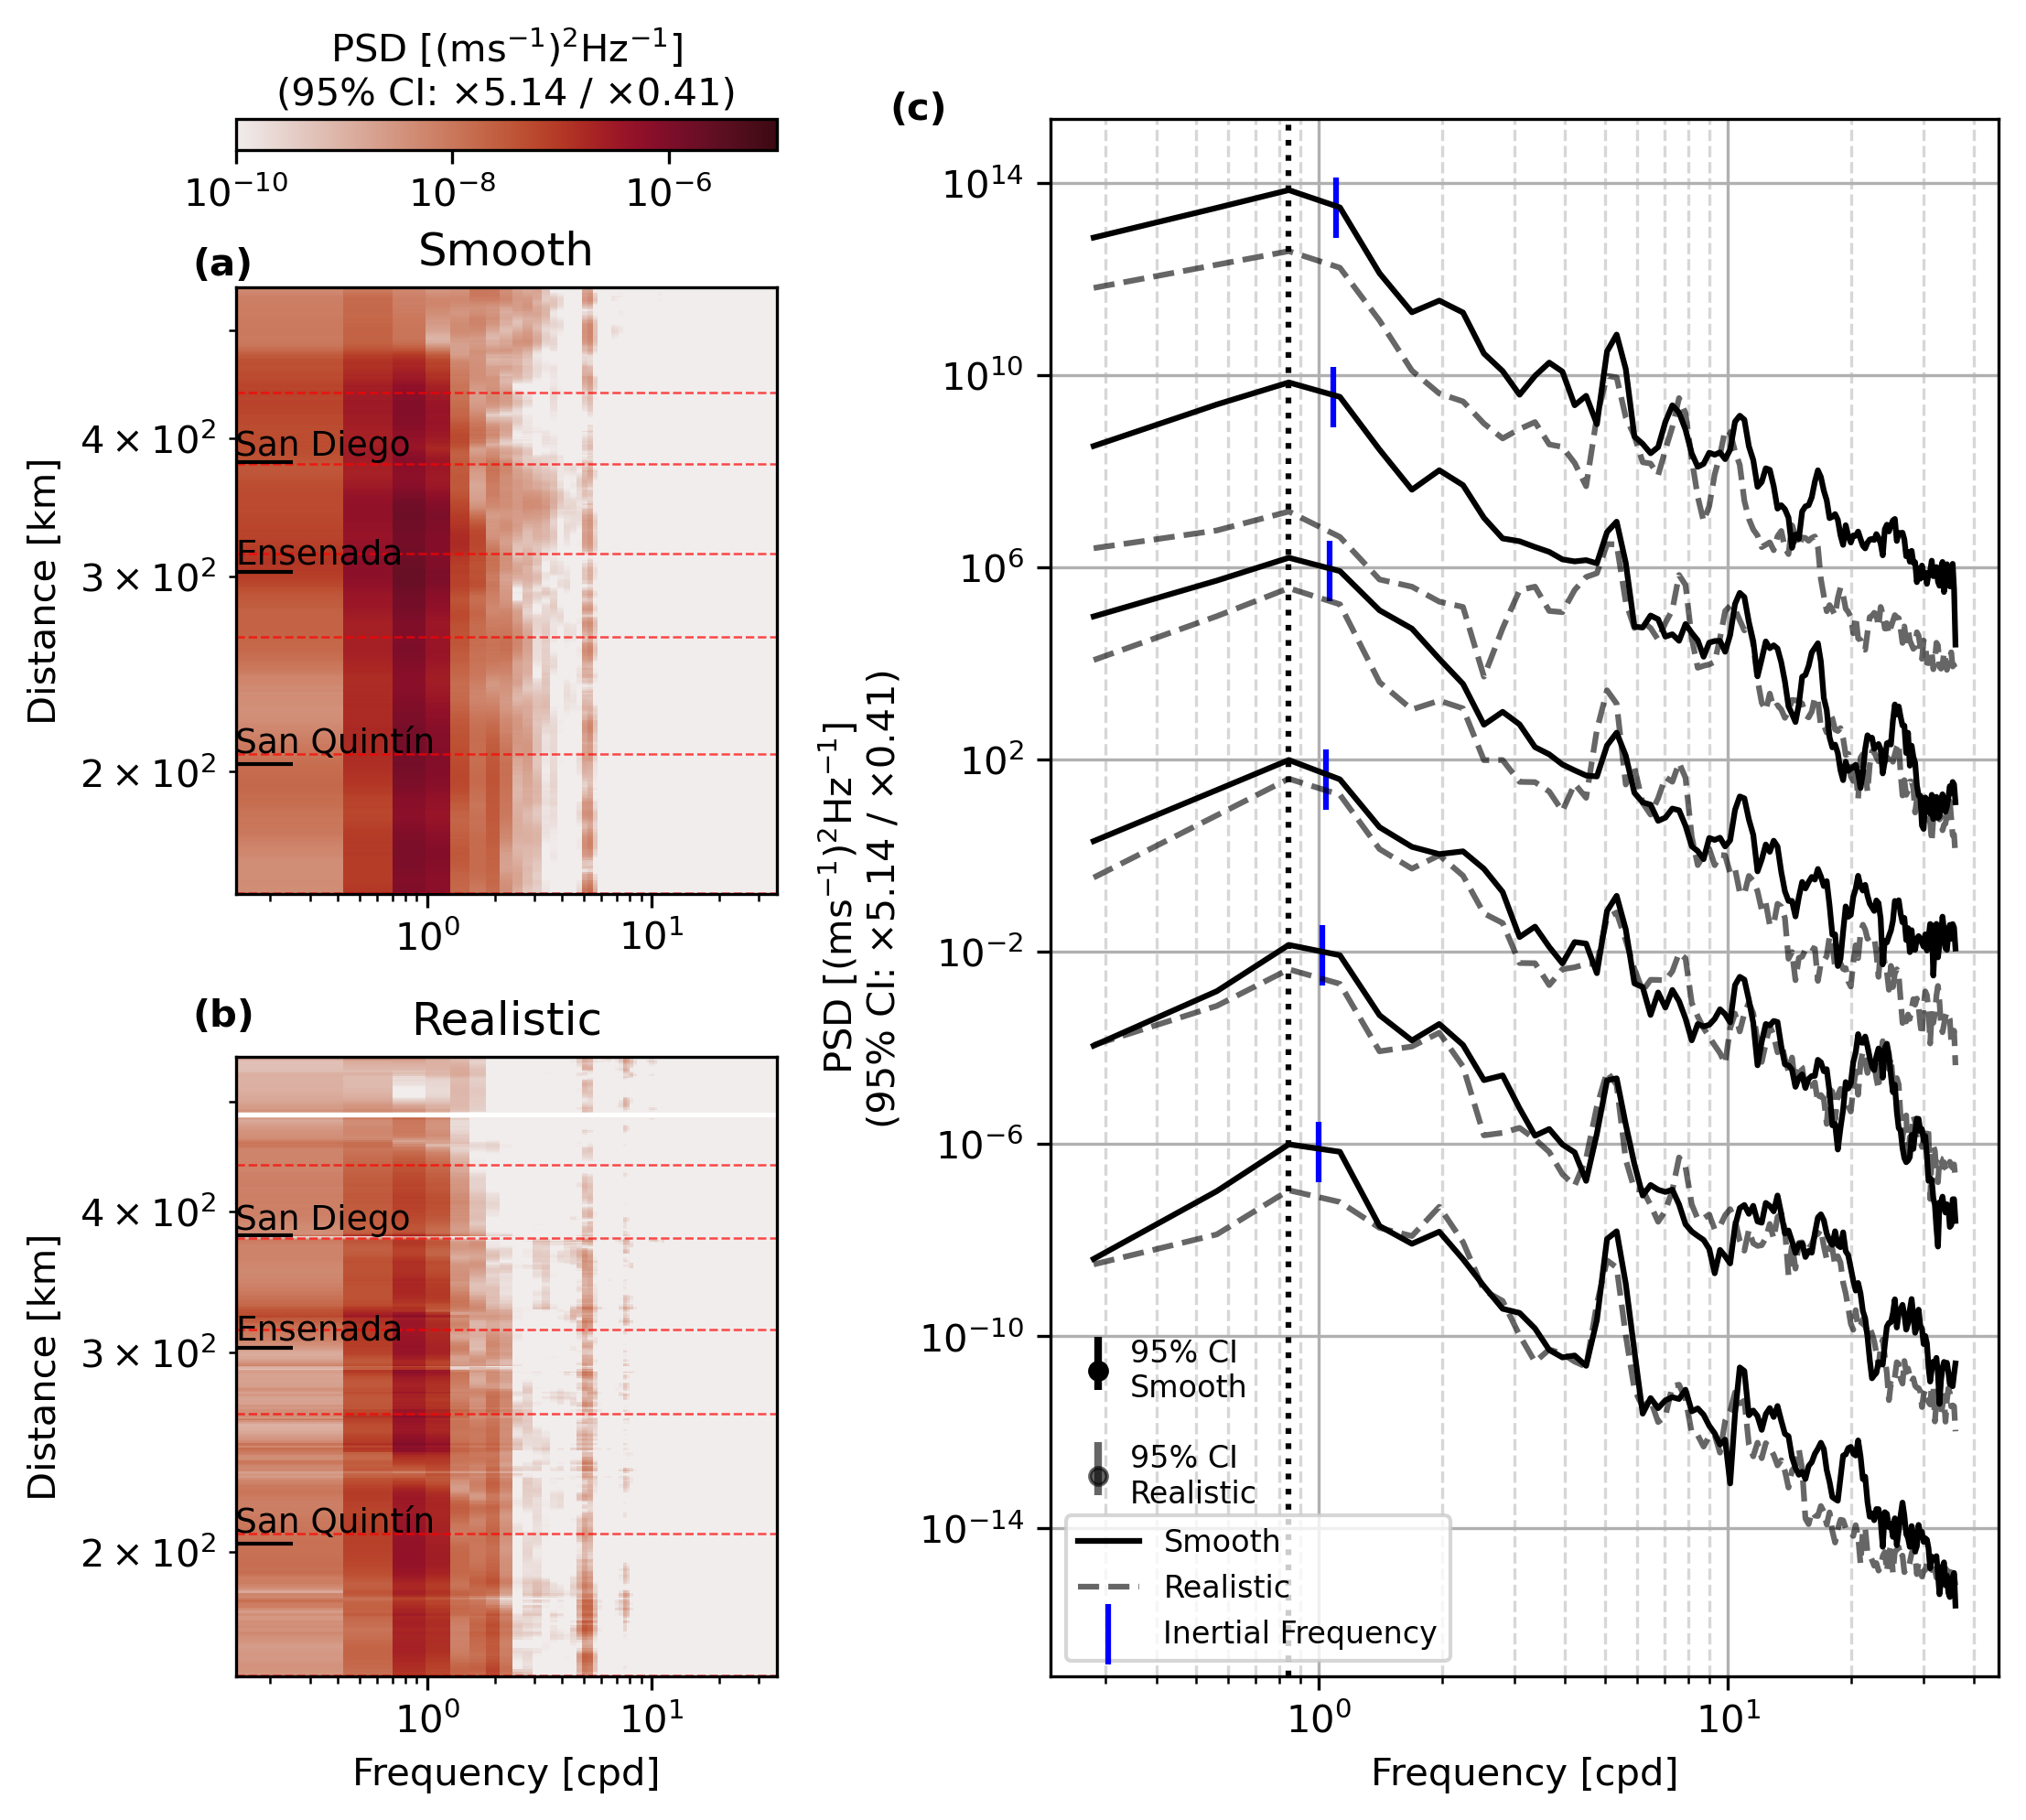

In [41]:
fig = plt.figure()
gs = GridSpec(nrows=2, ncols=5, height_ratios=[1, 0.8])

const=1
vmin=0
vmax=2

title=r'PSD [(ms$^{-1}$)$^{2}$Hz$^{-1}$]'+f'\n(95% CI: ×{uf:.2f} / ×{lf:.2f})'
xlab='Frequency [cpd]'
ylab='Distance [km]'

ax = fig.add_subplot(gs[0, 0:2])

ax.set_xscale('log')
ax.set_yscale('log')
#ax.set_xlim((0.1,10))

ax.text(-0.08, 1.02, '(a)', fontweight='bold', color='k', 
        transform=ax.transAxes)

cax = ax.pcolormesh(freqfilt*(24*3600),distVEL[:end],psdfilt[:end,:],norm=LogNorm(vmin=1e-10, vmax=1e-5),cmap=cmocean.cm.amp)

divider = make_axes_locatable(ax)
axdiv = divider.new_vertical(size = '5%', pad = 0.5)
fig.add_axes(axdiv)
cbar_ax = plt.colorbar(cax, cax=axdiv,orientation='horizontal')
cbar_ax.ax.xaxis.set_label_position("top")
cbar_ax.set_label(title)

#ax.set_yscale('log')
    
ax.set(ylabel=ylab)
ax.set_title('Smooth')


for ll, lab in zip(ind_lat,
                       ['San Quintín', 'Ensenada', 'San Diego']):
    ax.loglog(0.17, distVEL[ll], "_",markersize=20, color='black',zorder=5)
    ax.text(0.14, distVEL[ll]+5, lab, fontsize=9,color='black')
    
ax1 = fig.add_subplot(gs[1, 0:2])
ax1.set(xlabel=xlab, ylabel=ylab)
ax1.text(-0.08, 1.05, '(b)', fontweight='bold', color='k', 
        transform=ax1.transAxes)

ax1.set_xscale('log')
ax1.set_yscale('log')
#ax1.set_xlim((0.1,10))

cax1 = ax1.pcolormesh(freqfilto*(24*3600),distVELo[:endOrg],psdfilto[:endOrg,:], cmap=cmocean.cm.amp,norm=LogNorm(vmin=1e-10, vmax=1e-5))

#ax1.set_xlim((0,0.000016*(24*3600)))

for ll, lab in zip(ind_lat,
                       ['San Quintín', 'Ensenada', 'San Diego']):
    ax1.loglog(0.17, distVEL[ll], "_",markersize=20, color='black',zorder=5)
    ax1.text(0.14, distVEL[ll]+5, lab, fontsize=9,color='black')

ax1.set(xlabel=xlab, ylabel=ylab)

omega=(2*np.pi)/(23*60*60 + 56*60 + 4.1)


ax1.set_title('Realistic')

axin = fig.add_subplot(gs[:,2:])
axin.set_xscale('log')
axin.set_yscale('log')
#ax.set_xlim((0.1,10))
shift=1e2
for nr in np.arange(0,len(loclatIn),2):
    psdsmo=(psdfilt[loclatIn[nr]])*shift**nr
    psdre=(psdfilto[loclatInorg[nr]])*shift**nr
    
    if nr == 0:
        axin.plot((freqfilt)*(24*3600),psdsmo,c='k',linewidth=1.5,zorder=20,label='Smooth') 
        axin.plot((freqfilto)*(24*3600),psdre,alpha=0.6,c='k',linewidth=1.5,linestyle='dashed',zorder=10,label='Realistic') 
        axin.scatter((2*omega*np.sin(np.deg2rad(lat_acVEL[loclatIn[nr]]))*24*3600)/(2*np.pi),psdsmo[np.argmax(psdsmo)+1],color='blue',marker="|",s=250,label='Inertial Frequency')
        
    else:
        axin.plot((freqfilt)*(24*3600),psdsmo,c='k',linewidth=1.5,zorder=20) 
        axin.scatter((2*omega*np.sin(np.deg2rad(lat_acVEL[loclatIn[nr]]))*24*3600)/(2*np.pi),psdsmo[np.argmax(psdsmo)+1],color='blue',marker="|",s=250)
        axin.plot((freqfilto)*(24*3600),psdre,alpha=0.6,c='k',linewidth=1.5,linestyle='dashed',zorder=10) 


    ax1.axhline(distVEL[loclatIn[nr]],color='red',linestyle='dashed',linewidth=0.6,alpha=0.7)
    ax.axhline(distVEL[loclatIn[nr]],color='red',linestyle='dashed',linewidth=0.6,alpha=0.7)


f_ref = 0.008 *np.max(freqfilt) * (24*3600)
y_ref = np.median((psdfilt[loclatIn[0]]*const))*shift**1
f_refo =0.008 * np.max(freqfilto) * (24*3600)
y_refo = np.median((psdfilto[loclatInorg[0]]*const))*shift**0.5

low = y_ref * lf
hi = y_ref * uf 
lowre = y_refo * lf
hire = y_refo * uf

axin.vlines(f_ref, low, hi, color='k', linewidth=2)
axin.vlines(f_refo, lowre, hire, color='k', linewidth=2,alpha=0.6)
axin.scatter([f_ref], [y_ref], color='k', s=20, zorder=30)
axin.scatter([f_refo], [y_refo], color='k', s=20, zorder=30,alpha=0.6)
axin.text(f_ref*1.2, y_ref,'95% CI\nSmooth',fontsize=8, va='center')
axin.text(f_refo*1.2, y_refo,'95% CI\nRealistic',fontsize=8, va='center')
    

axin.axvline((freqfilt[np.argmax(psdfilt[loclatIn[nr]])])*(24*3600),linestyle='dotted',color='k',linewidth=1.5)
#axin.axvline(0.00001,linestyle='dotted',color='k',linewidth=1.5)
#axin.axvline((freqfilt[np.argmax(psdfilt[loclatIn[nr],10:])+10])*(24*3600),linestyle='dotted',color='k',linewidth=1.5)
axin.legend(loc='lower left',fontsize=8)
xlab='Frequency [cpd]'

#axin.set_xlim((0,0.000016*(24*3600)))

axin.set(xlabel=xlab, ylabel=title)
#axin.set_xticks(freqfilt[:15]*(24*3600))

axin.minorticks_on()

axin.grid(which='minor',linestyle='--', alpha=0.5)
axin.grid(which='major')
axin.set_axisbelow(True)

axin.text(-0.17, 1, '(c)', fontweight='bold', color='k', 
        transform=axin.transAxes)
    
fig.tight_layout()
plt.savefig('../figures/PSD_fig5.pdf',bbox_inches='tight')